# Metodología IV: Random Forest No Supervisado

## Índice de Esfuerzo Ciudadano — Agrupamiento por Proximidad de Bosque Aleatorio

Este notebook implementa un **Random Forest no supervisado** para agrupar los 665 trámites del estado de Hidalgo según su perfil de esfuerzo ciudadano. A diferencia de las metodologías anteriores — que construyen el índice como una combinación lineal de sub-índices ponderados —, este enfoque no asume ninguna relación lineal entre variables: el bosque aleatorio descubre la estructura latente de los datos a partir de los patrones de co-ocurrencia en hojas terminales.

**Variables:**  
`Tiempo_en_minutos` · `N_FORMATOS_FINAL` · `CONTEO_NETO` · `nivel_digitalizacion` · `TraCosto`

**Flujo general:**  
1. Generar datos sintéticos para contrastar con los reales.
2. Entrenar un RF clasificador (real vs. sintético).
3. Extraer la matriz de proximidad: P[i,j] = fracción de árboles donde i y j caen en la misma hoja.
4. Aplicar clustering jerárquico Ward sobre la matriz de distancias (1 − proximidad).
5. Calcular IEC_RF por distancia euclídea al centroide del cluster asignado, normalizado a [0, 100].

In [1]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.preprocessing import MinMaxScaler

## Carga de Datos

In [2]:
path = 'https://raw.githubusercontent.com/gonza98kg/Tramites-y-servicios/RandomForest/df_exp2.csv'

df = pd.read_csv(path)
df = df.drop(columns=['Indice_Esfuerzo_A'])
df.head()

,Idtram,Tramite,Secretaria,Dependencia,Domicilio,TraPersona,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,TraResolucionesFavorables,TraResolucionesNegativas,Porcentaje_Efectividad,TraCosto,visitas_totales,Visitas RUTS
0,7679.0,Transporte Público Masivo de Pasajeros Tuzobús.,Secretaría de Movilidad y Transporte,Sistema de Transporte Masivo de Hidalgo,Calle s/n Venta Prieta 42083 Pachuca De Soto P...,Social,5.00000,0,1,1,21096550,0,100.0,1,454.00000,3852.000000
1,1743.0,Impuesto sobre Tenencia y Refrendo Vehicular (...,Secretaría de Hacienda,Secretaría de Hacienda,Calle No. 1 Centro 42500 Pachuca De Soto Pachu...,Ambos,10.00000,2,8,12,368871,0,100.0,1,39912.00000,81886.000000
2,9229.0,Canje de Placas,Secretaría de Hacienda,Secretaría de Hacienda,Calle 801 Canutillo 42060 Pachuca De Soto Pach...,Ambos,20.00000,3,10,1,423743,0,100.0,1,5168.00000,82305.000000
3,533.0,Servicio de laboratorio clínico en el Hospital...,Organismos No Sectorizados,Sistema para el Desarrollo Integral de la Fami...,Boulevard s/n Venta Prieta 42083 Pachuca De So...,Social,22864.51619,0,2,1,620,0,100.0,0,667.00000,3305.417936
4,10885.0,Cambio de Propietario,Secretaría de Hacienda,Secretaría de Hacienda,Calle 1 Centro 42500 Actopan Actopan,Ambos,1440.00000,2,7,1,88932,0,100.0,1,2871.06701,25387.000000


El dataset utilizado es el mismo procesado en metodologías anteriores; no se requiere limpieza adicional.

Se emplean las **5 variables originales del IEC**, normalizadas al intervalo [0, 1] mediante MinMaxScaler:

| Variable | Descripción |
|---|---|
| `Tiempo_en_minutos` | Duración estimada del trámite |
| `N_FORMATOS_FINAL` | Número de formatos requeridos |
| `CONTEO_NETO` | Número de requisitos netos |
| `nivel_digitalizacion` | Nivel de digitalización (se invierte para ordenar esfuerzo) |
| `TraCosto` | Si el trámite implica costo (binaria) |

## Preprocesamiento

In [3]:
features = [
    'Tiempo_en_minutos',
    'N_FORMATOS_FINAL',
    'CONTEO_NETO',
    'nivel_digitalizacion',
    'TraCosto'
]

X = df[features].copy()

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

print(f'Shape: {X_scaled.shape}')
print(f'Nulos: {X_scaled.isnull().sum().sum()}')
print(f'\nRango por variable:')
print(X_scaled.agg(['min', 'max']).round(4).T)

Shape: (665, 5)
Nulos: 0

Rango por variable:
                      min  max
Tiempo_en_minutos     0.0  1.0
N_FORMATOS_FINAL      0.0  1.0
CONTEO_NETO           0.0  1.0
nivel_digitalizacion  0.0  1.0
TraCosto              0.0  1.0


## Generación de Datos Sintéticos

El truco del Random Forest no supervisado consiste en generar un conjunto de trámites ficticios que sirvan como clase de contraste. Cada variable ficticia se muestrea uniformemente dentro del rango observado [min, max] de los datos reales.

Al entrenar el RF para distinguir reales de sintéticos, el algoritmo aprende implícitamente la densidad conjunta de los datos reales: dos trámites que caen juntos en muchos árboles (alta proximidad) comparten un perfil similar en el espacio de cinco variables.

In [4]:
# ── Generar datos sintéticos ──────────────────────────────────────────────────
# Para cada variable se samplea uniformemente dentro de su rango observado [min, max]
np.random.seed(42)

X_sintetico = pd.DataFrame(
    {col: np.random.uniform(X_scaled[col].min(), X_scaled[col].max(), size=len(X_scaled))
     for col in features}
)

# ── Etiquetar: reales = 1, sintéticos = 0 ────────────────────────────────────
X_real_label = X_scaled.copy()
X_real_label['label'] = 1

X_sint_label = X_sintetico.copy()
X_sint_label['label'] = 0

# ── Concatenar ────────────────────────────────────────────────────────────────
X_combined = pd.concat([X_real_label, X_sint_label], ignore_index=True)
y_combined = X_combined.pop('label')

print(f'Dataset combinado: {X_combined.shape}')

Dataset combinado: (1330, 5)


## Entrenamiento del Random Forest

Se entrena un `RandomForestClassifier` de 1 000 árboles con `max_features='sqrt'` (≈ 2 variables por split). El accuracy de entrenamiento esperado es 1.0 — no es un indicador de sobreajuste en este contexto, sino una confirmación de que el RF logra separar perfectamente los datos reales de los sintéticos aleatorios, lo que significa que los datos reales **sí tienen estructura** (no son completamente aleatorios).

In [5]:
from sklearn.ensemble import RandomForestClassifier

# ── Entrenar el RandomForestClassifier ───────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=1000,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_combined, y_combined)

n_features_split = int(rf.n_features_in_ ** 0.5)
print(f'Árboles entrenados:    {rf.n_estimators}')
print(f'Variables por split:   {n_features_split} de {rf.n_features_in_}')
print(f'Accuracy entrenamiento: {rf.score(X_combined, y_combined):.4f}')

Árboles entrenados:    1000
Variables por split:   2 de 5
Accuracy entrenamiento: 1.0000


## Matriz de Proximidad

Para cada par de trámites (i, j), la proximidad P[i,j] cuenta la fracción de árboles en los que ambos cayeron en la misma hoja terminal. Un valor cercano a 1 indica que el RF los considera muy similares; cercano a 0, que rara vez comparten vecindad.

> **Proximidad promedio esperada** en datos con estructura débil: valores por debajo de 0.5 indican que los trámites no forman grupos naturales bien separados.

In [6]:
# ── Extraer hojas terminales para cada trámite real ──────────────────────────
# rf.apply() devuelve shape (n_muestras, n_arboles):
# cada valor es el índice de la hoja terminal donde cayó esa muestra en ese árbol
leaves = rf.apply(X_scaled.values)   # (665, 500)

# ── Calcular matriz de proximidad ────────────────────────────────────────────
# P[i,j] = fracción de árboles donde el trámite i y j cayeron en la misma hoja
n = len(X_scaled)
proximidad = np.zeros((n, n))

for t in range(rf.n_estimators):
    hoja = leaves[:, t]
    proximidad += (hoja[:, None] == hoja[None, :]).astype(float)

proximidad /= rf.n_estimators

# ── Verificación ─────────────────────────────────────────────────────────────
print(f'Shape matriz de proximidad: {proximidad.shape}')
print(f'Diagonal (debe ser 1.0):     {proximidad.diagonal().mean():.4f}')
print(f'Proximidad promedio:         {proximidad.mean():.4f}')
print(f'Proximidad mínima:           {proximidad.min():.4f}')
print(f'Proximidad máxima (fuera diag): {proximidad[~np.eye(n, dtype=bool)].max():.4f}')

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Shape matriz de proximidad: (665, 665)
Diagonal (debe ser 1.0):     1.0000
Proximidad promedio:         0.4761
Proximidad mínima:           0.0000
Proximidad máxima (fuera diag): 1.0000


## Clustering Jerárquico

La matriz de distancias (1 − proximidad) se pasa a un agrupamiento jerárquico aglomerativo con criterio de Ward, que minimiza la varianza intra-cluster en cada fusión. El dendrograma permite elegir visualmente el número de cortes; se seleccionan **3 clusters** como balance entre interpretabilidad y separación.

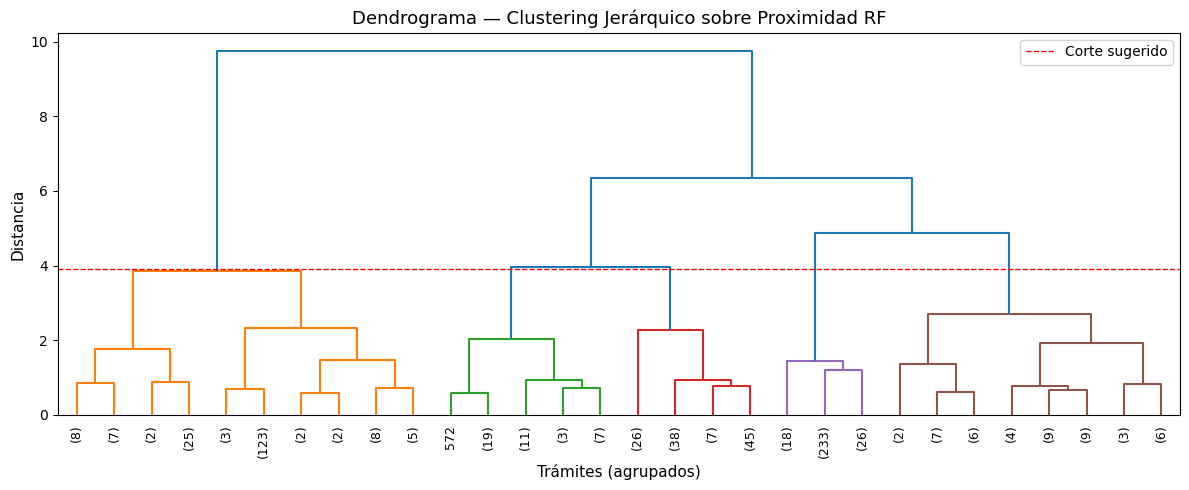

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# ── Convertir proximidad a distancia ─────────────────────────────────────────
distancia = 1 - proximidad
np.fill_diagonal(distancia, 0)   # asegurar diagonal exacta en 0
distancia_condensada = squareform(distancia)

# ── Clustering jerárquico aglomerativo (método Ward) ─────────────────────────
Z = linkage(distancia_condensada, method='ward')

# ── Dendrograma ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9, color_threshold=0.4*max(Z[:,2]))
ax.set_title('Dendrograma — Clustering Jerárquico sobre Proximidad RF', fontsize=13)
ax.set_xlabel('Trámites (agrupados)', fontsize=11)
ax.set_ylabel('Distancia', fontsize=11)
ax.axhline(y=0.4*max(Z[:,2]), color='red', linestyle='--', linewidth=1, label='Corte sugerido')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Asignar clusters según el corte ──────────────────────────────────────────
n_clusters = 3
df['cluster'] = fcluster(Z, t=n_clusters, criterion='maxclust')

# ── Distribución ──────────────────────────────────────────────────────────────
dist = df['cluster'].value_counts().sort_index().rename({1:'Cluster 1', 2:'Cluster 2', 3:'Cluster 3'})
display(dist.to_frame('n_trámites').style.set_caption('Distribución de trámites por cluster'))

# ── Perfil mediano ────────────────────────────────────────────────────────────
perfil = df.groupby('cluster')[features].median().round(2)
perfil.index = ['Cluster 1', 'Cluster 2', 'Cluster 3']
perfil['n_trámites'] = df.groupby('cluster')['Tramite'].count().values

display(perfil.style
    .background_gradient(cmap='YlOrRd', subset=features)
    .set_caption('Perfil mediano por cluster')
    .format(precision=2)
)

,n_trámites
cluster,
Cluster 1,185
Cluster 2,157
Cluster 3,323


,Tiempo_en_minutos,N_FORMATOS_FINAL,CONTEO_NETO,nivel_digitalizacion,TraCosto,n_trámites
Cluster 1,7200.00,0.00,1.00,1.00,0.00,185
Cluster 2,2880.00,1.00,2.00,7.00,1.00,157
Cluster 3,7200.00,1.00,2.00,1.00,1.00,323


## IEC_RF: Índice de Esfuerzo Ciudadano

El score se construye en dos pasos:

1. **Score base por cluster**: los clusters se ordenan por esfuerzo mediano (con `nivel_digitalizacion` invertido) y se asignan bases 23.33 / 46.67 / 70.00.
2. **Ajuste continuo**: dentro de cada cluster, la distancia euclídea al centroide se normaliza a [0, 30] y se suma a la base — los trámites más alejados del centroide (perfil más extremo) reciben el mayor puntaje.

El resultado final se re-escala a [0, 100].

In [9]:
# ── Centroides en espacio escalado ───────────────────────────────────────────
X_scaled_cluster = X_scaled.copy()
X_scaled_cluster['cluster'] = df['cluster'].values
centroides = X_scaled_cluster.groupby('cluster')[features].mean()

# ── Distancia euclídea de cada trámite a su centroide ────────────────────────
def distancia_euclidea(row):
    c         = row['cluster']
    centroide = centroides.loc[c].values
    punto     = X_scaled.loc[row.name, features].values
    return np.sqrt(np.sum((punto - centroide) ** 2))

df['dist_centroide'] = df.apply(distancia_euclidea, axis=1)

# ── Ordenar clusters por esfuerzo (nivel_digitalizacion invertido) ────────────
# Mayor digitalización = MENOR esfuerzo → se invierte: 1 - valor_escalado
X_esfuerzo = X_scaled_cluster[features].copy()
X_esfuerzo['nivel_digitalizacion'] = 1 - X_esfuerzo['nivel_digitalizacion']
X_esfuerzo['cluster'] = X_scaled_cluster['cluster']

orden_esfuerzo = (
    X_esfuerzo.groupby('cluster')[features]
    .median()
    .sum(axis=1)
    .sort_values(ascending=False)
)
print('Orden de clusters por esfuerzo (nivel_digitalizacion invertido):')
print(orden_esfuerzo.round(4))

# ── Score base por cluster ────────────────────────────────────────────────────
ranking      = orden_esfuerzo.rank(ascending=True)
base_cluster = (ranking / ranking.max() * 70).round(2)
print('\nBase asignada por cluster:')
print(base_cluster)

# ── Score continuo ────────────────────────────────────────────────────────────
def score_continuo(row):
    base   = base_cluster[row['cluster']]
    mask   = df['cluster'] == row['cluster']
    d_min  = df.loc[mask, 'dist_centroide'].min()
    d_max  = df.loc[mask, 'dist_centroide'].max()
    d_norm = (row['dist_centroide'] - d_min) / (d_max - d_min + 1e-9)
    return base + d_norm * 30

df['score_raw'] = df.apply(score_continuo, axis=1)

# ── Normalizar a [0, 100] ─────────────────────────────────────────────────────
s_min = df['score_raw'].min()
s_max = df['score_raw'].max()
df['IEC_RF'] = ((df['score_raw'] - s_min) / (s_max - s_min) * 100).round(2)

# ── Vista previa ─────────────────────────────────────────────────────────────
print(f'\nRango IEC_RF: [{df["IEC_RF"].min()}, {df["IEC_RF"].max()}]')
print(f'Media:   {df["IEC_RF"].mean():.2f}')
print(f'Mediana: {df["IEC_RF"].median():.2f}')
print(f'Std:     {df["IEC_RF"].std():.2f}')

cols = ['Tramite', 'Secretaria', 'cluster', 'IEC_RF']
display(df[cols].sort_values('IEC_RF', ascending=False).head(15).reset_index(drop=True))

Orden de clusters por esfuerzo (nivel_digitalizacion invertido):
cluster
3    2.2306
2    1.7607
1    1.0806
dtype: float64

Base asignada por cluster:
cluster
3    70.00
2    46.67
1    23.33
dtype: float64

Rango IEC_RF: [0.0, 100.0]
Media:   42.65
Mediana: 48.49
Std:     26.66


,Tramite,Secretaria,cluster,IEC_RF
0,Impartición de justicia de conflictos laborale...,Secretaría de Trabajo y Previsión Social,3,100.00
1,"Registro de Sindicatos, Expedición de la Toma ...",Secretaría de Trabajo y Previsión Social,3,100.00
2,Recurso de Revocación Estatal,Secretaría de Hacienda,3,99.87
3,Convocatoria del Instituto de Formación Profes...,Secretaría de Seguridad Pública,3,98.39
4,Preinscripciones de Educación Básica,Secretaría de Educación Pública,3,98.00
5,Titulación UPFIM,Secretaría de Educación Pública,3,97.51
6,Escrituras Públicas para personas que han teni...,Secretaría de Gobierno,3,93.87
7,Impartición de Justicia en Conflictos Laborale...,Secretaría de Trabajo y Previsión Social,3,91.47
8,Tramitación de la Declaración de Beneficiarios...,Secretaría de Trabajo y Previsión Social,3,91.46
9,"Representación Legal a Trabajadores, Sindicato...",Secretaría de Trabajo y Previsión Social,3,91.21


## Resultados y Discusión

### Distribución del IEC_RF

El IEC_RF cubre el rango completo [0, 100] con media 42.65 y mediana 48.49, distribución más asimétrica que la Metodología II (media 49.37). La desviación estándar de 26.66 refleja la separación entre los tres clusters.

### Similitud entre Clusters 1 y 3

El agrupamiento sugiere tres niveles de esfuerzo, pero los clusters 1 y 3 presentan perfiles medianos muy similares en la mayoría de las variables. Este hallazgo es consistente con lo encontrado en el análisis de PCA y correlación:

- Las cinco variables del IEC son **estadísticamente independientes** (cargas PCA ≈ 0.994 por componente; B^T C B ≈ I).
- Ninguna variable domina la varianza del conjunto: los eigenvalores oscilan entre 1.47 y 0.58, con la primera componente explicando sólo el 29.4 % de la varianza.
- La **proximidad promedio de 0.4761** — por debajo de 0.5 — confirma que los trámites no forman grupos naturales bien separados en el espacio de cinco dimensiones.

En otras palabras, el RF no puede encontrar fronteras nítidas porque los datos **no tienen estructura correlacional**: cada trámite varía de forma casi independiente en cada variable, lo que produce una nube difusa donde los límites entre clusters son arbitrarios. PCA lo diagnosticó primero; la proximidad promedio del RF lo confirma.

### Trámites de Alto Esfuerzo (cluster 3)

A pesar de la separación débil, el cluster de mayor esfuerzo concentra trámites con tiempos elevados, múltiples requisitos y baja digitalización, principalmente de **Secretaría de Trabajo y Previsión Social** y **Secretaría de Educación Pública**. Los cuatro trámites que ya aparecieron en el top de las Metodologías I y II vuelven a estar entre los primeros puestos, lo que refuerza su identificación como procesos de alta carga burocrática independientemente del enfoque metodológico.

### Limitaciones

- La independencia estadística de las variables limita la capacidad del RF para encontrar clusters con alta cohesión interna.
- La escala de bases (23.33 / 46.67 / 70.00) implica que el 30 % restante del score depende de la distancia intra-cluster, introduciendo un componente continuo que puede enmascarar diferencias reales entre trámites de distintos clusters.
- Al igual que en metodologías anteriores, los 244 trámites con datos faltantes quedan fuera del análisis.